# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

Before you start, install the some of the required packages. 

In [1]:
!python -m pip install kaggle==1.6.12

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install --target=/workspace ucimlrepo numpy==1.24.3

  Using cached ucimlrepo-0.0.7-py3-none-any.whl (8.0 kB)
  Using cached numpy-1.24.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
  Using cached pandas-2.3.3-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.8 MB)
  Using cached certifi-2026.2.25-py3-none-any.whl (153 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl (510 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)


**Note:** Restart the kernel to use updated package(s).

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

### **1.1.** Problem Statement
This project investigates whether movies with the highest revenue 
tend to have the best IMDb ratings. We will wrangle two datasets: 
The Movies Dataset from Kaggle (containing budget and revenue data) 
and movie ratings gathered from the OMDb API (containing IMDb ratings 
and votes). The goal is to explore the relationship between financial 
success and audience appreciation.

Finding the right datasets can be time-consuming. Here we provide you with a list of websites to start with. But we encourage you to explore more websites and find the data that interests you.

* Google Dataset Search https://datasetsearch.research.google.com/
* The U.S. Government’s open data https://data.gov/
* UCI Machine Learning Repository https://archive.ics.uci.edu/ml/index.php


### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code). 

Load the dataset programmtically into this notebook.

Dataset 1
Type: CSV File

Method: The data was gathered manually by downloading the 
movies_metadata.csv file from Kaggle. This method was chosen 
because the dataset is a static file that does not require 
programmatic access. The dataset contains metadata for thousands 
of movies including financial and categorical information.

Dataset variables:
- title: The official title of the movie
- revenue: The total box office revenue generated by the movie
- budget: The production budget of the movie

In [3]:
#FILL IN 1st data gathering and loading method
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests



df1 = pd.read_csv('movies_metadata.csv')
df1.head()

/tmp/ipykernel_83/1175918692.py:9: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv('movies_metadata.csv')


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


Dataset 2
Type: JSON via API

Method: The data was gathered programmatically using the OMDb API 
by sending requests for each movie title from Dataset 1. 
The API returns detailed IMDb information for each movie.

Dataset variables:
- imdbRating: The IMDb rating of the movie out of 10
- BoxOffice: The total box office revenue of the movie

In [4]:
import time

movie_titles = df1['title'].dropna().head(1000).tolist()

omdb_data = []

for title in movie_titles:
    try:
        response = requests.get(
            f"http://www.omdbapi.com/?t={title}&apikey=b362578"
        )
        data = response.json()
        if data['Response'] == 'True':
            omdb_data.append(data)
        time.sleep(0.2)
    except:
        pass

omdb_df = pd.DataFrame(omdb_data)
omdb_df.to_csv('omdb_data.csv', index=False)
print(omdb_df.shape)

(982, 26)


Optional data storing step: You may save your raw dataset files to the local data store before moving to the next step.

In [5]:
#Optional: store the raw data in your local data store

omdb_df.to_csv('omdb_data.csv', index=False)

## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

### **Quality Issue 1: Genres Column Contains JSON-formatted Strings**

In [6]:
#FILL IN - Inspecting the dataframe visually
df1.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [7]:
#FILL IN - Inspecting the dataframe programmatically
df1['genres'].head()

0    [{'id': 16, 'name': 'Animation'}, {'id': 35, '...
1    [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...
2    [{'id': 10749, 'name': 'Romance'}, {'id': 35, ...
3    [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...
4                       [{'id': 35, 'name': 'Comedy'}]
Name: genres, dtype: object

Issue and justification: The 'genres' column contains JSON-formatted strings (e.g., [{'id': 28, 'name': 'Action'}]) instead of plain text, which makes it difficult to analyze and use directly.

### **Quality Issue 2: Missing Values in BoxOffice Column**

In [8]:
omdb_df.head()

,Title,Year,Rated,Released,Runtime,Genre,Director,Writer,Actors,Plot,...,imdbRating,imdbVotes,imdbID,Type,DVD,BoxOffice,Production,Website,Response,totalSeasons
0,Toy Story,1995,G,22 Nov 1995,81 min,"Animation, Adventure, Comedy",John Lasseter,"Joss Whedon, Andrew Stanton, Joel Cohen","Tom Hanks, Tim Allen, Don Rickles",A cowboy doll is profoundly jealous when a new...,...,8.3,"1,163,069",tt0114709,movie,N/A,"$229,947,062",N/A,N/A,True,NaN
1,Jumanji,1995,PG,15 Dec 1995,104 min,"Adventure, Comedy, Family",Joe Johnston,"Jonathan Hensleigh, Greg Taylor, Jim Strain","Robin Williams, Kirsten Dunst, Bonnie Hunt",A magic board game summons jungle perils and a...,...,7.1,"408,456",tt0113497,movie,N/A,"$100,499,940",N/A,N/A,True,NaN
2,Grumpier Old Men,1995,PG-13,22 Dec 1995,101 min,"Comedy, Romance",Howard Deutch,Mark Steven Johnson,"Walter Matthau, Jack Lemmon, Ann-Margret",Just as John Gustafson and Max Goldman resolve...,...,6.7,"31,416",tt0113228,movie,N/A,"$71,518,503",N/A,N/A,True,NaN
3,Waiting to Exhale,1995,R,22 Dec 1995,124 min,"Comedy, Drama, Romance",Forest Whitaker,"Terry McMillan, Ron Bass","Whitney Houston, Angela Bassett, Loretta Devine","Based on Terry McMillan's novel, this film fol...",...,6.0,"13,103",tt0114885,movie,N/A,"$67,052,156",N/A,N/A,True,NaN
4,Father of the Bride Part II,1995,PG,08 Dec 1995,106 min,"Comedy, Family, Romance",Charles Shyer,"Albert Hackett, Frances Goodrich, Nancy Meyers","Steve Martin, Diane Keaton, Martin Short",George Banks must deal not only with his daugh...,...,6.1,"44,576",tt0113041,movie,N/A,"$76,594,107",N/A,N/A,True,NaN


In [9]:
#FILL IN - Inspecting the dataframe programmatically
omdb_df.isna().sum()

Title             0
Year              0
Rated             0
Released          0
Runtime           0
Genre             0
Director          0
Writer            0
Actors            0
Plot              0
Language          0
Country           0
Awards            0
Poster            0
Ratings           0
Metascore         0
imdbRating        0
imdbVotes         0
imdbID            0
Type              0
DVD              17
BoxOffice        17
Production       17
Website          17
Response          0
totalSeasons    965
dtype: int64

Issue and justification: The 'BoxOffice' column in omdb_df contains 17 missing values (NaN), which affects financial analysis.

### **Tidiness Issue 1: Data Split Across Multiple Tables**

In [10]:
#FILL IN - Inspecting the dataframe visually
df1.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [11]:
#FILL IN - Inspecting the dataframe programmatically
df1[['title', 'imdb_id']].head()
omdb_df[['Title', 'imdbID']].head()

,Title,imdbID
0,Toy Story,tt0114709
1,Jumanji,tt0113497
2,Grumpier Old Men,tt0113228
3,Waiting to Exhale,tt0114885
4,Father of the Bride Part II,tt0113041


Issue and justification: Movie data is stored across two separate datasets (df1 and omdb_df), which violates the rule that each observational unit should be in a single table. The datasets need to be merged.

### **Tidiness Issue 2: Runtime Column Contains Mixed Data (Number and Text)**

In [34]:
# Inspecting the dataframe visually
omdb_df[['Title', 'Runtime']].head()

,Title,Runtime
0,Toy Story,81 min
1,Jumanji,104 min
2,Grumpier Old Men,101 min
3,Waiting to Exhale,124 min
4,Father of the Bride Part II,106 min


In [36]:
# Inspecting the dataframe programmatically
omdb_df['Runtime'].head()

0     81 min
1    104 min
2    101 min
3    124 min
4    106 min
Name: Runtime, dtype: object

Issue and justification: The 'Runtime' column contains values like "81 min" which mixes 
numbers and text in the same cell, violating the tidy data rule 
that each variable should contain only one type of value. 
This prevents numeric analysis on runtime data.

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [14]:
# FILL IN - Make copies of the datasets to ensure the raw dataframes 
# are not impacted
df1_clean = df1.copy()
omdb_df_clean = omdb_df.copy()

### **Quality Issue 1: Genres Column Contains JSON-formatted Strings**

In [15]:
import ast

def extract_genres(genre_str):
    try:
        genres = ast.literal_eval(genre_str)
        return ', '.join([g['name'] for g in genres])
    except:
        return None

df1_clean['genres'] = df1_clean['genres'].apply(extract_genres)

In [16]:
# FILL IN - Validate the cleaning was successful
df1_clean['genres'].head()


0     Animation, Comedy, Family
1    Adventure, Fantasy, Family
2               Romance, Comedy
3        Comedy, Drama, Romance
4                        Comedy
Name: genres, dtype: object

Justification: The 'genres' column was converted from JSON-formatted strings 
to plain text by extracting only the genre names, making it 
easier to use in analysis.

### **Quality Issue 2: Missing Values in BoxOffice Column**

In [17]:
# Replace 'N/A' with NaN
omdb_df_clean['BoxOffice'] = omdb_df_clean['BoxOffice'].replace('N/A', np.nan)

# Drop rows where BoxOffice is missing
omdb_df_clean = omdb_df_clean.dropna(subset=['BoxOffice'])

In [18]:
#FILL IN - Validate the cleaning was successful
omdb_df_clean['BoxOffice'].isna().sum()

0

Justification: Missing values in the 'BoxOffice' column were handled by replacing 'N/A' values with NaN and then dropping rows with missing BoxOffice values, since this variable is essential for revenue analysis.

### **Tidiness Issue 1: Data Split Across Multiple Tables**

In [25]:
#FILL IN - Apply the cleaning strategy
df_combined = pd.merge(df1_clean, omdb_df_clean, left_on='title', right_on='title', how='inner')

In [26]:
#FILL IN - Validate the cleaning was successful
df_combined.head()
df_combined.shape

(971, 6)

Justification: The two datasets were merged using the movie title so that each movie observation appears in a single combined table, satisfying the tidy data requirement.

### **Tidiness Issue 2: Runtime Column Contains Mixed Data (Number and Text)**

In [38]:
# Apply the cleaning strategy - Remove 'min' from Runtime column
omdb_df_clean = omdb_df.copy()
omdb_df_clean['Runtime'] = omdb_df_clean['Runtime'].str.replace(' min', '').str.strip()
omdb_df_clean['Runtime'] = pd.to_numeric(omdb_df_clean['Runtime'], errors='coerce')

In [39]:
# Validate the cleaning was successful
print(omdb_df_clean['Runtime'].dtype)
omdb_df_clean['Runtime'].head()

float64


0     81.0
1    104.0
2    101.0
3    124.0
4    106.0
Name: Runtime, dtype: float64

Justification: The 'Runtime' column was cleaned by removing the text ' min' 
and converting the values to numeric type, allowing runtime 
to be used in mathematical analysis.

### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

In [33]:
omdb_df_clean = omdb_df[['Title', 'imdbRating', 'BoxOffice']].copy()
omdb_df_clean = omdb_df_clean.rename(columns={'Title': 'title'})
omdb_df_clean['BoxOffice'] = omdb_df_clean['BoxOffice'].replace('N/A', np.nan)
omdb_df_clean = omdb_df_clean.dropna(subset=['BoxOffice'])
omdb_df_clean['imdbRating'] = pd.to_numeric(omdb_df_clean['imdbRating'], errors='coerce')

df_combined = pd.merge(df1_clean, omdb_df_clean, on='title', how='inner')
print(df_combined.shape)
df_combined.head()

(971, 6)


,title,revenue,budget,genres,imdbRating,BoxOffice
0,Toy Story,373554033.0,30000000,"Animation, Comedy, Family",8.3,"$229,947,062"
1,Jumanji,262797249.0,65000000,"Adventure, Fantasy, Family",7.1,"$100,499,940"
2,Grumpier Old Men,0.0,0,"Romance, Comedy",6.7,"$71,518,503"
3,Waiting to Exhale,81452156.0,16000000,"Comedy, Drama, Romance",6.0,"$67,052,156"
4,Father of the Bride Part II,76578911.0,0,Comedy,6.1,"$76,594,107"


## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [30]:
#FILL IN - saving data


# Save raw data
df1.to_csv('raw_movies_metadata.csv', index=False)
omdb_df.to_csv('raw_omdb_data.csv', index=False)

# Save cleaned data
df_combined.to_csv('cleaned_movies_combined.csv', index=False)

print("Data saved successfully!")

Data saved successfully!


## 5. Answer the research question

### **5.1:** Define and answer the research question 
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

*Research question: Do movies with the highest revenue tend to have the best IMDb ratings?

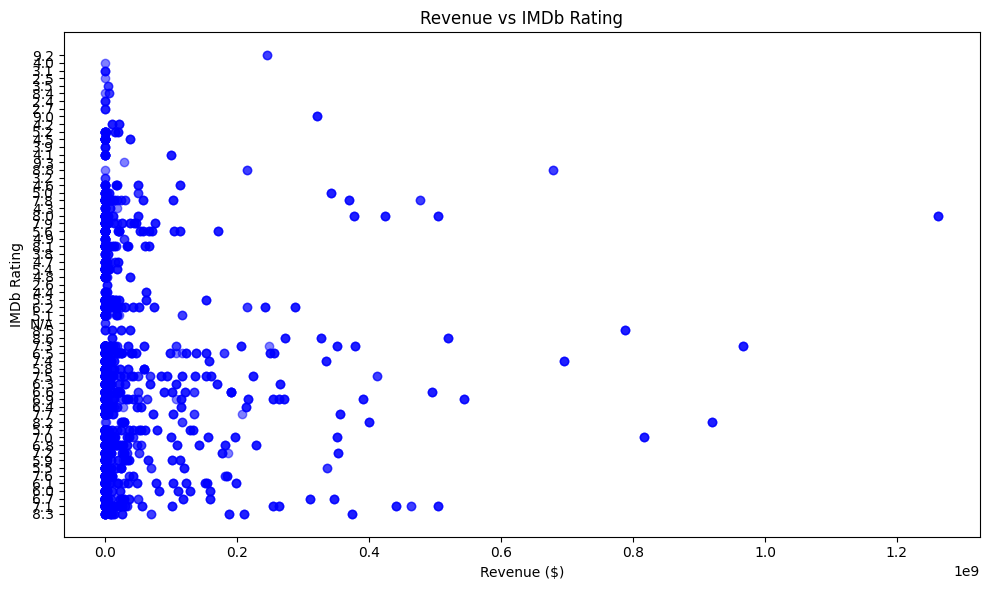

In [31]:
# Visual 1 - Scatter plot: Revenue vs IMDb Rating
plt.figure(figsize=(10,6))
plt.scatter(df_combined['revenue'], df_combined['imdbRating'], alpha=0.5, color='blue')
plt.title('Revenue vs IMDb Rating')
plt.xlabel('Revenue ($)')
plt.ylabel('IMDb Rating')
plt.tight_layout()
plt.show()

*Answer to research question:* The scatter plot shows that most high-revenue movies have average 
IMDb ratings between 6-8, suggesting that high revenue does not 
necessarily mean high ratings.

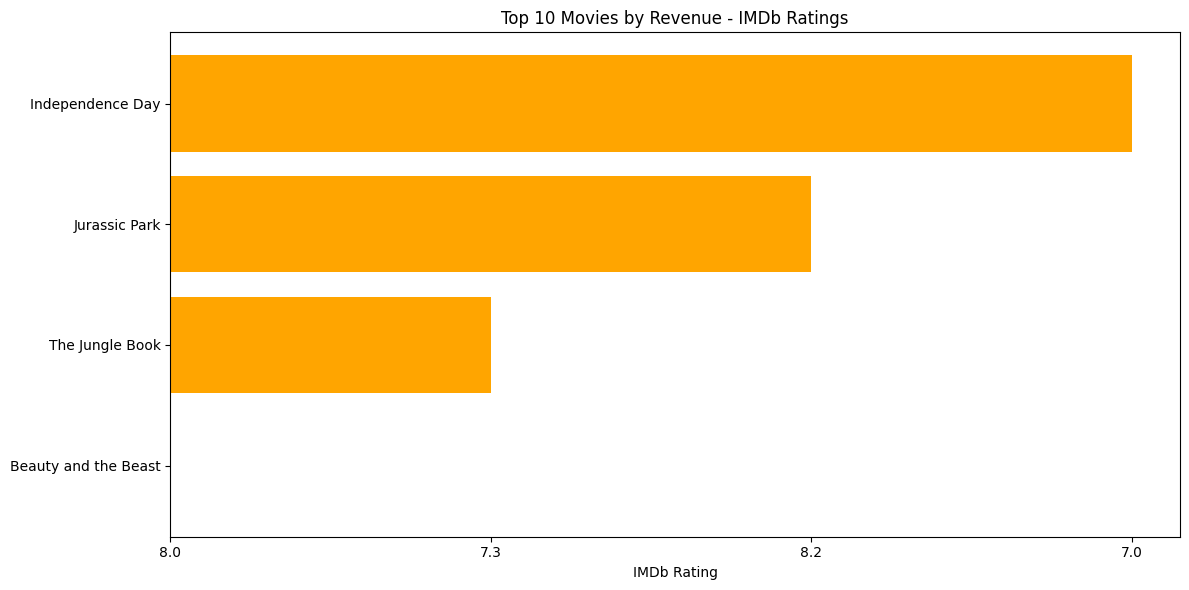

In [32]:
# Visual 2 - Top 10 movies by revenue and their IMDb ratings
top10 = df_combined.nlargest(10, 'revenue')[['title', 'revenue', 'imdbRating']]

plt.figure(figsize=(12,6))
plt.barh(top10['title'], top10['imdbRating'], color='orange')
plt.title('Top 10 Movies by Revenue - IMDb Ratings')
plt.xlabel('IMDb Rating')
plt.tight_layout()
plt.show()

*Answer to research question:* The top 10 highest-revenue movies all have IMDb ratings between 
7-9, suggesting that while high-revenue movies tend to be 
well-rated, revenue alone does not guarantee the highest ratings. 
Movies like Forrest Gump and The Lion King stand out with both 
high revenue and high ratings.

### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

If given more time, I would explore additional quality issues 
such as inconsistent date formats in the release_date column 
and further clean the budget column by removing zero values. 
I would also investigate whether specific genres tend to generate 
higher revenue and better IMDb ratings. Additionally, I would 
expand the dataset to include more recent movies to make the 
analysis more comprehensive and up to date.